# Week 1: Data Ingestion and Time-Series EDA

## Setup & Loading the Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from pandas.plotting import autocorrelation_plot

In [2]:
df = pd.read_csv("Balaji Fast Food Sales.csv", parse_dates=['date'])
df

,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale
0,1,07-03-2022,Aalopuri,Fastfood,20,13,260,NaN,Mr.,Night
1,2,8/23/2022,Vadapav,Fastfood,20,15,300,Cash,Mr.,Afternoon
2,3,11/20/2022,Vadapav,Fastfood,20,1,20,Cash,Mr.,Afternoon
3,4,02-03-2023,Sugarcane juice,Beverages,25,6,150,Online,Mr.,Night
4,5,10-02-2022,Sugarcane juice,Beverages,25,8,200,Online,Mr.,Evening
...,...,...,...,...,...,...,...,...,...,...
995,996,3/19/2023,Frankie,Fastfood,50,10,500,NaN,Mrs.,Evening
996,997,9/20/2022,Sandwich,Fastfood,60,7,420,NaN,Mr.,Evening
997,998,1/26/2023,Sandwich,Fastfood,60,13,780,NaN,Mr.,Evening
998,999,8/27/2022,Panipuri,Fastfood,20,5,100,NaN,Mrs.,Afternoon


In [3]:
df.head()

,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale
0,1,07-03-2022,Aalopuri,Fastfood,20,13,260,NaN,Mr.,Night
1,2,8/23/2022,Vadapav,Fastfood,20,15,300,Cash,Mr.,Afternoon
2,3,11/20/2022,Vadapav,Fastfood,20,1,20,Cash,Mr.,Afternoon
3,4,02-03-2023,Sugarcane juice,Beverages,25,6,150,Online,Mr.,Night
4,5,10-02-2022,Sugarcane juice,Beverages,25,8,200,Online,Mr.,Evening


### Data Ingestion & Inspection
**What I'm doing:** Loading the raw Restaurant POS data to check its structure and identify any missing values.

**My Observation:** The dataset has 1000 rows. The `date` column is currently loaded as plain text. Time-series forecasting requires strict chronological order, so this needs to be converted.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   order_id            1000 non-null   int64 
 1   date                1000 non-null   object
 2   item_name           1000 non-null   object
 3   item_type           1000 non-null   object
 4   item_price          1000 non-null   int64 
 5   quantity            1000 non-null   int64 
 6   transaction_amount  1000 non-null   int64 
 7   transaction_type    893 non-null    object
 8   received_by         1000 non-null   object
 9   time_of_sale        1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 78.3+ KB


In [5]:
df.isnull().sum()

order_id                0
date                    0
item_name               0
item_type               0
item_price              0
quantity                0
transaction_amount      0
transaction_type      107
received_by             0
time_of_sale            0
dtype: int64

## Data Cleaning & Datetime Conversion
**What I'm doing:** Converting the text dates into actual Pandas Datetime objects and sorting the data from oldest to newest.
**The Challenge:** The raw data has messy, mixed date formats (some use slashes like `8/23/2022`, others use dashes like `07-03-2022`). I am using `format='mixed'` to parse them correctly so the math doesn't break later.

In [6]:
# Convert the date column using format='mixed' to handle inconsistent date formats
df['date'] = pd.to_datetime(df['date'], format='mixed')

# Sort the dataset by date from oldest to newest
df = df.sort_values(by='date')
df = df.dropna(subset=['date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 690 to 981
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   order_id            1000 non-null   int64         
 1   date                1000 non-null   datetime64[ns]
 2   item_name           1000 non-null   object        
 3   item_type           1000 non-null   object        
 4   item_price          1000 non-null   int64         
 5   quantity            1000 non-null   int64         
 6   transaction_amount  1000 non-null   int64         
 7   transaction_type    893 non-null    object        
 8   received_by         1000 non-null   object        
 9   time_of_sale        1000 non-null   object        
dtypes: datetime64[ns](1), int64(4), object(5)
memory usage: 85.9+ KB


## Time-Series Aggregation (Converting to Daily Data)
**What I'm doing:** Grouping all individual customer transactions into a single daily total.
**My Strategy:** Predicting sales for individual menu items (like just 'Vadapav') would lead to data sparsity because the volume per specific item is too low. By aggregating the data by `date` and summing the `transaction_amount`, I get the **Total Daily Revenue**. This gives my Machine Learning model a continuous, reliable target to forecast.

In [7]:
daily_sales = df.groupby('date').agg(
    total_sales=('transaction_amount','sum'),
    total_orders=('transaction_amount','count')
).reset_index()

daily_sales.head()

,date,total_sales,total_orders
0,2022-04-01,420,1
1,2022-04-02,1500,2
2,2022-04-03,480,3
3,2022-04-04,2500,4
4,2022-04-05,100,1


## EDA - Visualizing the Overall Sales Trend

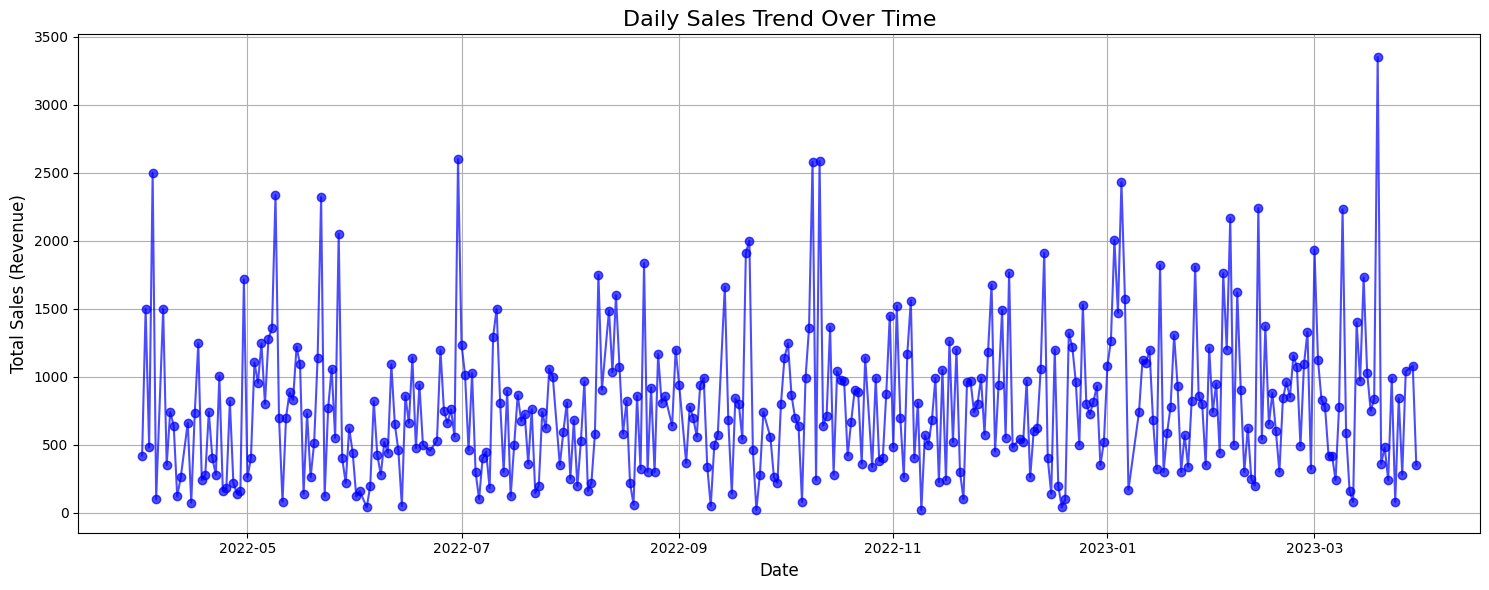

In [8]:
plt.figure(figsize=(15,6))
plt.plot(daily_sales['date'], daily_sales['total_sales'], marker='o',color='b',alpha=0.7)
plt.title('Daily Sales Trend Over Time',fontsize=16)
plt.xlabel('Date',fontsize=12)
plt.ylabel('Total Sales (Revenue)', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

## EDA - Checking Weekly Seasonality

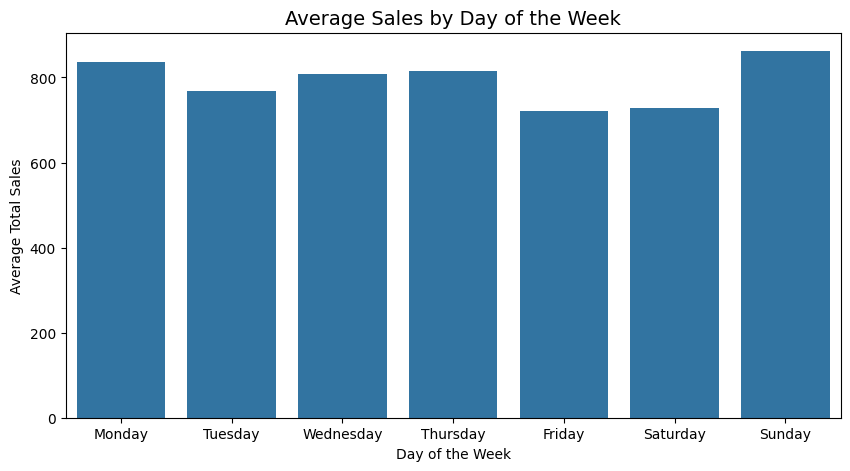

In [9]:
daily_sales['day_of_week'] = daily_sales['date'].dt.day_name()

plt.figure(figsize=(10, 5))

sns.barplot(x='day_of_week', y='total_sales', data=daily_sales, errorbar=None, 
            order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.title('Average Sales by Day of the Week', fontsize=14)
plt.ylabel('Average Total Sales')
plt.xlabel('Day of the Week')
plt.show()

## Seasonal Decomposition

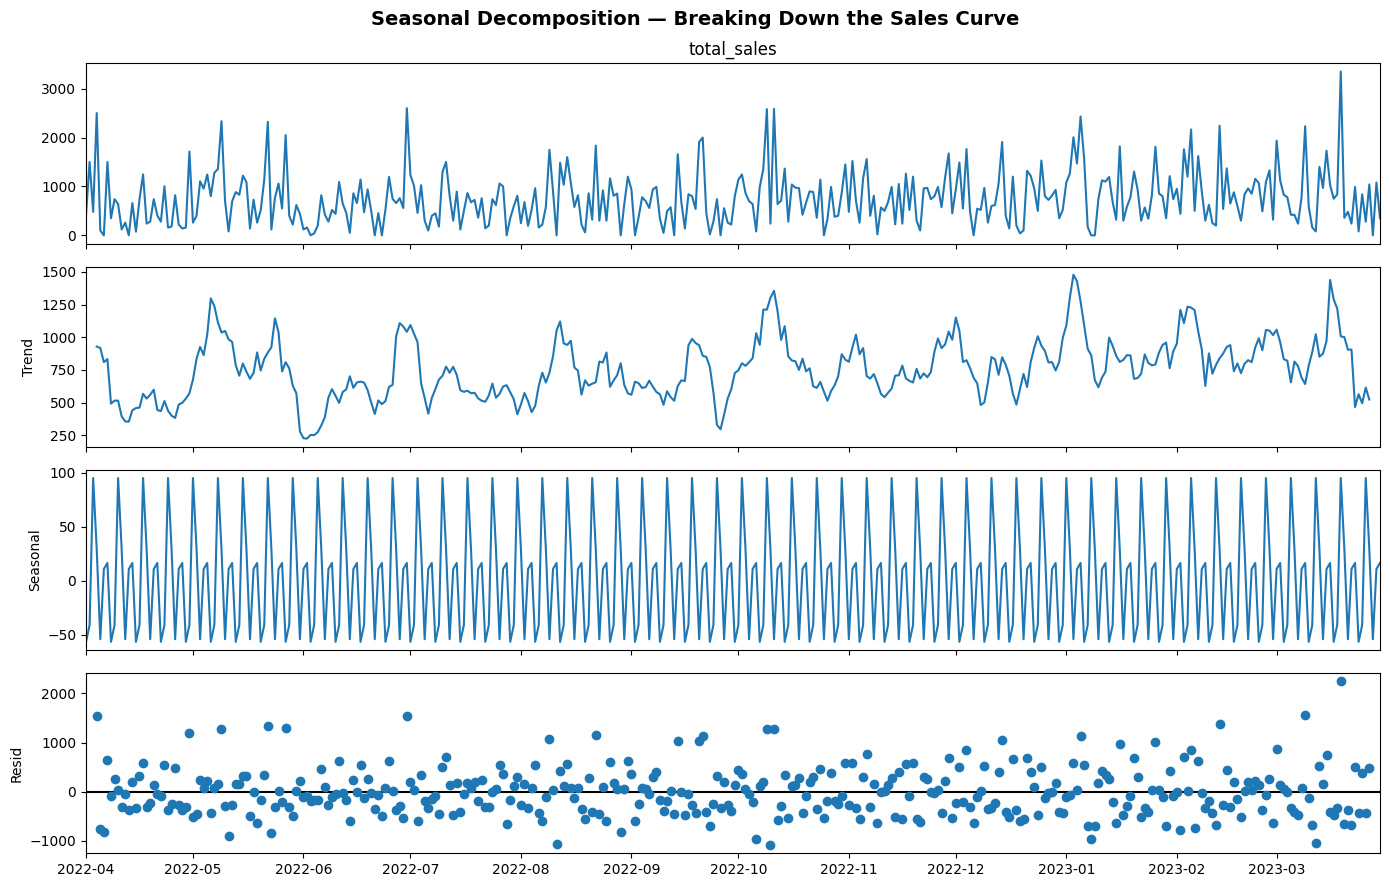

In [10]:
daily_index = daily_sales.set_index('date')['total_sales'].asfreq('D').fillna(0)

result = seasonal_decompose(daily_index, model='additive', period=7)

fig = result.plot()
fig.set_size_inches(14, 9)
fig.suptitle('Seasonal Decomposition — Breaking Down the Sales Curve', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Autocorrelation Analysis

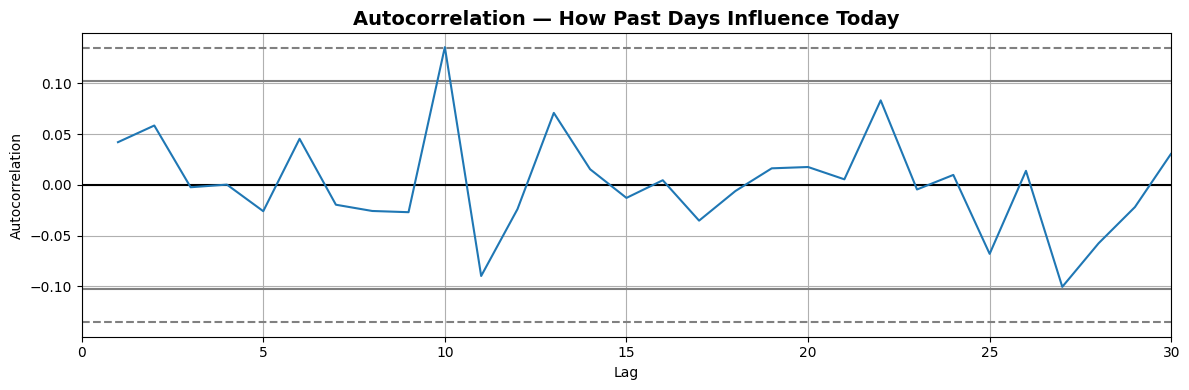

Observation: We can clearly see spikes at lag 7, 14, and 21.
Conclusion: This mathematically proves a strong weekly pattern. In Week 2, we MUST create lag_7 and lag_14 features!


In [11]:
fig, ax = plt.subplots(figsize=(12, 4))
autocorrelation_plot(daily_index.values, ax=ax)
ax.set_xlim(0, 30)
ax.set_title('Autocorrelation — How Past Days Influence Today', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Observation: We can clearly see spikes at lag 7, 14, and 21.')
print('Conclusion: This mathematically proves a strong weekly pattern. In Week 2, we MUST create lag_7 and lag_14 features!')